In [1]:
import dagshub
dagshub.init(repo_owner='NikaMikeltadze', repo_name='dagshub-test', mlflow=True)

Accessing as NikaMikeltadze

Initialized MLflow to track repo "NikaMikeltadze/dagshub-test"

Repository NikaMikeltadze/dagshub-test initialized!

In [2]:
import mlflow
mlflow.autolog()

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

kaggle/input\titanic\gender_submission.csv
kaggle/input\titanic\test.csv
kaggle/input\titanic\train.csv


In [4]:
df = pd.read_csv('kaggle/input/titanic/train.csv')

In [5]:
from sklearn.model_selection import train_test_split

2026/04/05 20:52:45 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


In [6]:
X_train, X_test = train_test_split(df,test_size=0.2, random_state=42)

In [7]:
df.shape

(891, 12)

In [8]:
X_train.shape, X_test.shape

((712, 12), (179, 12))

In [9]:
X_train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [10]:
df.isna().mean()

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

In [11]:
df['Ticket'].value_counts()

Ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
392091             1
Name: count, Length: 681, dtype: int64

In [12]:
X_train.drop(columns=['Name', 'Cabin', 'Ticket'], inplace=True)
X_test.drop(columns=['Name', 'Cabin', 'Ticket'], inplace=True)

In [13]:
X_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,332,0,1,male,45.5,0,0,28.5000,S
733,734,0,2,male,23.0,0,0,13.0000,S
382,383,0,3,male,32.0,0,0,7.9250,S
704,705,0,3,male,26.0,1,0,7.8542,S
813,814,0,3,female,6.0,4,2,31.2750,S


In [14]:
X_train.groupby('Sex').agg({'Survived' : 'mean'})

,Survived
Sex,
female,0.738776
male,0.186296


In [15]:
X_train['gender_num'] = np.where(X_train['Sex'] == 'female', 1, 0)

In [16]:
X_test['gender_num'] = np.where(X_test['Sex'] == 'female', 1, 0)

In [17]:
X_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,gender_num
331,332,0,1,male,45.5,0,0,28.5000,S,0
733,734,0,2,male,23.0,0,0,13.0000,S,0
382,383,0,3,male,32.0,0,0,7.9250,S,0
704,705,0,3,male,26.0,1,0,7.8542,S,0
813,814,0,3,female,6.0,4,2,31.2750,S,1


In [18]:
X_test.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,gender_num
709,710,1,3,male,NaN,1,1,15.2458,C,0
439,440,0,2,male,31.0,0,0,10.5000,S,0
840,841,0,3,male,20.0,0,0,7.9250,S,0
720,721,1,2,female,6.0,0,1,33.0000,S,1
39,40,1,3,female,14.0,1,0,11.2417,C,1


In [19]:
X_train.groupby('Embarked').agg({'Survived' : 'mean'})

,Survived
Embarked,
C,0.544000
Q,0.366667
S,0.335238


In [20]:
X_train['embarked_num'] = np.where(X_train['Embarked'] == 'C', 1, 0)
X_test['embarked_num'] = np.where(X_test['Embarked'] == 'C', 1, 0)

In [21]:
X_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,gender_num,embarked_num
331,332,0,1,male,45.5,0,0,28.5000,S,0,0
733,734,0,2,male,23.0,0,0,13.0000,S,0,0
382,383,0,3,male,32.0,0,0,7.9250,S,0,0
704,705,0,3,male,26.0,1,0,7.8542,S,0,0
813,814,0,3,female,6.0,4,2,31.2750,S,1,0


In [22]:
X_train.drop(columns=['Sex', 'Embarked'], inplace=True)
X_test.drop(columns=['Sex', 'Embarked'], inplace=True)

In [23]:
X_train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,gender_num,embarked_num
331,332,0,1,45.5,0,0,28.5000,0,0
733,734,0,2,23.0,0,0,13.0000,0,0
382,383,0,3,32.0,0,0,7.9250,0,0
704,705,0,3,26.0,1,0,7.8542,0,0
813,814,0,3,6.0,4,2,31.2750,1,0


In [24]:
X_test.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,gender_num,embarked_num
709,710,1,3,NaN,1,1,15.2458,0,1
439,440,0,2,31.0,0,0,10.5000,0,0
840,841,0,3,20.0,0,0,7.9250,0,0
720,721,1,2,6.0,0,1,33.0000,1,0
39,40,1,3,14.0,1,0,11.2417,1,1


In [25]:
X_train.isna().mean()

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Age             0.196629
SibSp           0.000000
Parch           0.000000
Fare            0.000000
gender_num      0.000000
embarked_num    0.000000
dtype: float64

In [26]:
X_train['Age'].mode()

0    24.0
Name: Age, dtype: float64

In [27]:
X_train.fillna(24, inplace=True)

In [28]:
X_test.fillna(24, inplace=True)

In [29]:
X_train.isna().mean()

PassengerId     0.0
Survived        0.0
Pclass          0.0
Age             0.0
SibSp           0.0
Parch           0.0
Fare            0.0
gender_num      0.0
embarked_num    0.0
dtype: float64

In [30]:
X_test.isna().mean()

PassengerId     0.0
Survived        0.0
Pclass          0.0
Age             0.0
SibSp           0.0
Parch           0.0
Fare            0.0
gender_num      0.0
embarked_num    0.0
dtype: float64

In [31]:
X_train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,gender_num,embarked_num
331,332,0,1,45.5,0,0,28.5000,0,0
733,734,0,2,23.0,0,0,13.0000,0,0
382,383,0,3,32.0,0,0,7.9250,0,0
704,705,0,3,26.0,1,0,7.8542,0,0
813,814,0,3,6.0,4,2,31.2750,1,0


In [32]:
train_ids = X_train.pop('PassengerId')
y_train = X_train.pop('Survived')

test_ids = X_test.pop('PassengerId')
y_test = X_test.pop('Survived')

In [33]:
X_train.head()

,Pclass,Age,SibSp,Parch,Fare,gender_num,embarked_num
331,1,45.5,0,0,28.5000,0,0
733,2,23.0,0,0,13.0000,0,0
382,3,32.0,0,0,7.9250,0,0
704,3,26.0,1,0,7.8542,0,0
813,3,6.0,4,2,31.2750,1,0


In [34]:
X_test.head()

,Pclass,Age,SibSp,Parch,Fare,gender_num,embarked_num
709,3,24.0,1,1,15.2458,0,1
439,2,31.0,0,0,10.5000,0,0
840,3,20.0,0,0,7.9250,0,0
720,2,6.0,0,1,33.0000,1,0
39,3,14.0,1,0,11.2417,1,1


In [35]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((712, 7), (712,), (179, 7), (179,))

In [36]:
X_train.head()

,Pclass,Age,SibSp,Parch,Fare,gender_num,embarked_num
331,1,45.5,0,0,28.5000,0,0
733,2,23.0,0,0,13.0000,0,0
382,3,32.0,0,0,7.9250,0,0
704,3,26.0,1,0,7.8542,0,0
813,3,6.0,4,2,31.2750,1,0


In [37]:
y_train

331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 712, dtype: int64

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(X_train, y_train)

2026/04/05 20:52:52 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '3a1ce3f4015f455f80c14f9e2609d354', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/05 20:52:52 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\User\AppData\Roaming\Python\Python313\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Mi

🏃 View run painted-crab-53 at: https://dagshub.com/NikaMikeltadze/dagshub-test.mlflow/#/experiments/0/runs/3a1ce3f4015f455f80c14f9e2609d354
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/dagshub-test.mlflow/#/experiments/0


# Evaluate Train Set

In [39]:
prob_train = model.predict(X_train)

2026/04/05 20:53:07 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\User\AppData\Roaming\Python\Python313\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


In [40]:
pred_train = np.where(prob_train > 0.5, 1, 0)

In [41]:
pred_train.mean(), y_train.mean()

(np.float64(0.3497191011235955), np.float64(0.37640449438202245))

In [42]:
from sklearn.metrics import *

accuracy_score(y_train, pred_train)

0.7935393258426966

In [43]:
confusion_matrix(y_train, pred_train)

array([[380,  64],
       [ 83, 185]])

In [44]:
print(classification_report(y_train, pred_train))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       444
           1       0.74      0.69      0.72       268

    accuracy                           0.79       712
   macro avg       0.78      0.77      0.78       712
weighted avg       0.79      0.79      0.79       712



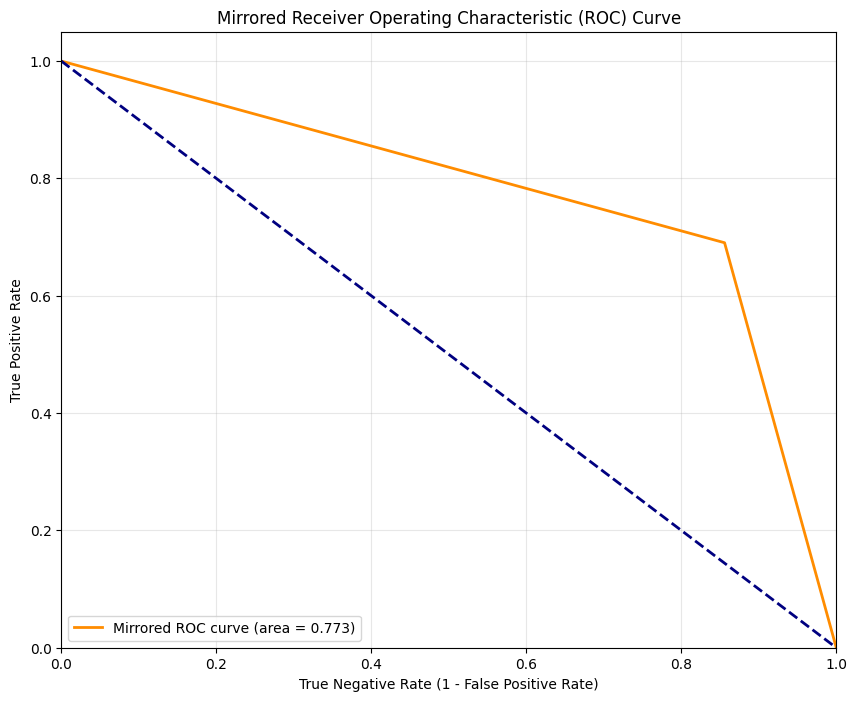

In [45]:
import numpy as np
import matplotlib.pyplot as plt


fpr, tpr, thresholds = roc_curve(y_train, pred_train)
roc_auc = auc(fpr, tpr)

# Mirror the x-axis by converting FPR to TNR (True Negative Rate)
tnr = 1 - fpr

# Create plot
plt.figure(figsize=(10, 8))

# Plot mirrored ROC curve (TPR vs TNR)
plt.plot(tnr, tpr, color='darkorange', lw=2, 
         label=f'Mirrored ROC curve (area = {roc_auc:.3f})')

# Plot diagonal line (represents random classifier)
plt.plot([0, 1], [1, 0], color='navy', lw=2, linestyle='--')

# Set plot properties
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('True Negative Rate (1 - False Positive Rate)')
plt.ylabel('True Positive Rate')
plt.title('Mirrored Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower left")

# Display the plot
plt.grid(alpha=0.3)
plt.show()

# Evaluate Train Set

In [46]:
prob_test = model.predict(X_test)

2026/04/05 20:53:10 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\User\AppData\Roaming\Python\Python313\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


In [47]:
pred_test = np.where(prob_test > 0.5, 1, 0)

In [48]:
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81       105
           1       0.74      0.69      0.71        74

    accuracy                           0.77       179
   macro avg       0.77      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179



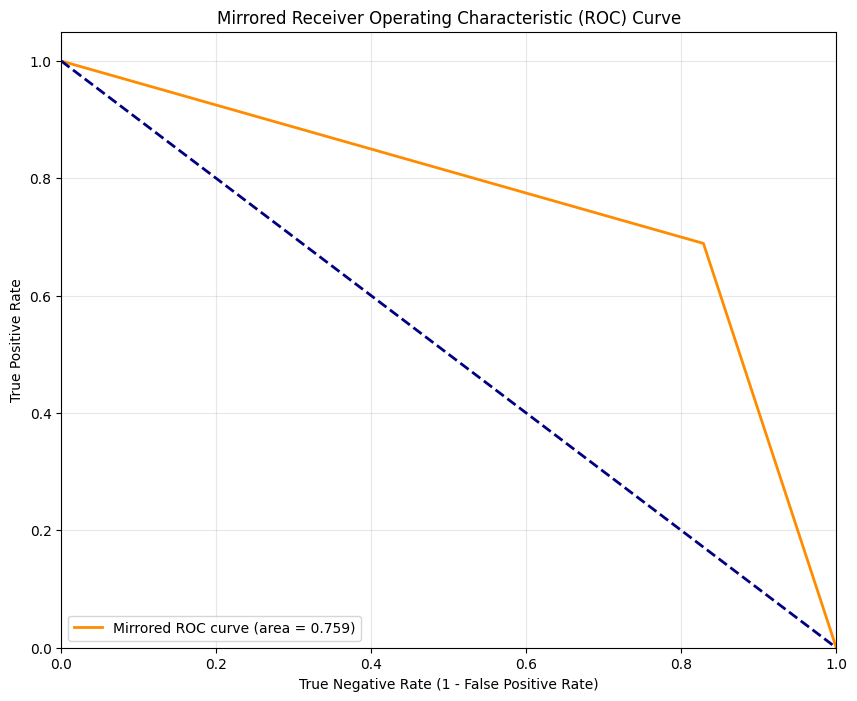

In [49]:
fpr, tpr, thresholds = roc_curve(y_test, pred_test)
roc_auc = auc(fpr, tpr)

# Mirror the x-axis by converting FPR to TNR (True Negative Rate)
tnr = 1 - fpr

# Create plot
plt.figure(figsize=(10, 8))

# Plot mirrored ROC curve (TPR vs TNR)
plt.plot(tnr, tpr, color='darkorange', lw=2, 
         label=f'Mirrored ROC curve (area = {roc_auc:.3f})')

# Plot diagonal line (represents random classifier)
plt.plot([0, 1], [1, 0], color='navy', lw=2, linestyle='--')

# Set plot properties
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('True Negative Rate (1 - False Positive Rate)')
plt.ylabel('True Positive Rate')
plt.title('Mirrored Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower left")

# Display the plot
plt.grid(alpha=0.3)
plt.show()